# Longstaff-Schwartz Methods (Regression-Based Methods)

In this notebook, I implement the Longstaff-Schwartz methods for American put option pricing.
The content of this notebook is based on Chapter 8 of the book "Monte Carlo Methods in Financial Engineering" by Paul Glasserman.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Parameters

In [2]:
num_basis = 4

In [3]:
time_step = 0.1
terminal_time = 1
time_grid = np.arange(0, terminal_time + time_step, time_step)
num_steps = len(time_grid)

num_total_samples = 1000

initial_stock_price = 100
riskless = 0.03
strike_price = 100

# "sigma" is a volatility term of GBM
sigma = 0.2

# 2. Functions

In [4]:
# basis_funcs[k](x) = x^k
basis_funcs = []
for i in range(num_basis):
    basis_funcs.append(lambda x, i=i: (x/strike_price)**i)

In [5]:
def put_intrinsic_value(current_price):
    return max(0, strike_price - current_price)

# 3. Simulation of stock price paths

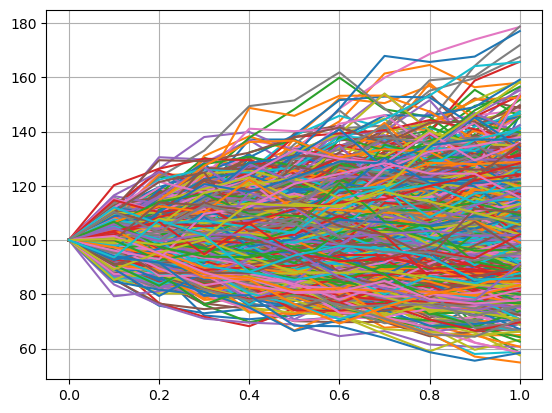

In [6]:
stock_price = np.zeros((num_total_samples, num_steps))
W = np.zeros((num_total_samples, num_steps))
for i in range(num_total_samples):
    for j in range(num_steps-1):
        Z = np.random.normal(loc=0,scale=1)
        W[i][j+1] = W[i][j] + np.sqrt(time_grid[j+1] - time_grid[j]) * Z

for i in range(num_total_samples):
    stock_price[i][0] = initial_stock_price
    for j in range(1,num_steps):
        stock_price[i][j] = initial_stock_price * np.exp((riskless - 1/2 * sigma**2) * time_grid[j] + sigma * W[i][j])

for i in range(num_total_samples):
    plt.plot(time_grid, stock_price[i])
plt.grid(True)
plt.show()

# 4. Backward Induction

In [7]:
intrinsic_value = np.zeros((num_total_samples, num_steps))

for i in range(num_total_samples):
    for j in range(num_steps):
        intrinsic_value[i][j] = put_intrinsic_value(stock_price[i][j])

continuation_value = np.zeros((num_total_samples, num_steps))
option_value = np.zeros((num_total_samples, num_steps))
option_value[:,num_steps-1] = intrinsic_value[:,num_steps-1]

for j in reversed(range(1, num_steps-1)):
    coeff_vec = np.zeros(num_basis)
    B_psi_V = np.zeros(num_basis)
    B_psi = np.zeros((num_basis, num_basis))
    for i in range(num_total_samples):
        for q in range(num_basis):
            for r in range(num_basis):
                B_psi[q][r] += (
                    basis_funcs[q](stock_price[i][j]) *
                    basis_funcs[r](stock_price[i][j])
                )
            B_psi_V[q] += (
                basis_funcs[q](stock_price[i][j]) *
                np.exp(-riskless * time_step) *
                option_value[i][j+1]
            )
    B_psi /= num_total_samples
    B_psi_V /= num_total_samples
    B_psi_inv = np.linalg.pinv(B_psi)
    coeff_vec = np.dot(B_psi_inv, B_psi_V)
    for i in range(num_total_samples):
        vector = np.array([
            basis_funcs[m](stock_price[i][j])
            for m in range(num_basis)
        ])
        continuation_value[i][j] = np.dot(coeff_vec, vector)
        option_value[i][j] = max(
            intrinsic_value[i][j],
            continuation_value[i][j]
        )

# 5. Computation of the estimator

In [8]:
estimator = np.exp(- riskless * time_step) * np.mean(option_value[:,1])
print(estimator)

6.9018228226816305


# References

1. Glasserman, P. (2003) *Monte Carlo Methods in Financial Engineering*. Springer, New York.